<a href="https://colab.research.google.com/github/harshpre5/Artificial_Neural_Networks_14444188_HS_6009CMD/blob/main/14444188_ANN_PART_A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Section:1** **Setup** **and** **datset**

## 1) Mounting Google Drive to access dataset

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2) importing Libraries
following cell  loads all the required libraries for the notebook. To ensure the notebook runs correctly and to avoid redundant imports, all libraries have been consolidated here and categorized.

In [3]:
import os # For directory operations and path handling.
import random # Used to set random seed for Python's built-in random operations.
import numpy as np # Used for numerical operations and setting numpy random seed.
import pandas as pd # Used to load the CSV file into a DataFrame.
import matplotlib.pyplot as plt # Used to set global plot parameters and create basic visualizations.
import seaborn as sns # Used to set global visualization themes and create statistical plots.
from sklearn.model_selection import train_test_split # Used to split the dataset into train, validation, and test sets.
from sklearn.preprocessing import StandardScaler, LabelEncoder # Used to standardize feature values and encode the target class.
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score # Used to evaluate classification model performance.
import tensorflow as tf # Used to set the TensorFlow random seed for reproducibility.
from tensorflow import keras # Used as the primary deep learning framework.
from tensorflow.keras import layers # Used to define the layers of the neural network architectures.


# Section 1: Data Loading and Initial Inspection
This section sets up reproducible random seeds, configures global plotting preferences, and loads the dataset. It also performs basic data formatting, type casting, and quality checks.

In [4]:
# 1. Reproducibility
# Setting fixed seeds for all random number generators to ensure it runs
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# 2. Plot settings
# Establishing consistent global styling and dimensions for all visualizations.
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
sns.set_theme(style="whitegrid")

print("Libraries imported and random seeds set.")

Libraries imported and random seeds set.


In [5]:
# 3. File path
file_path = "/content/drive/MyDrive/sensorless_drive_diagnosis_verified.csv"

# 4. Reading CSV
# Loading the dataset. low_memory=False prevents pandas from guessing datatypes in chunks
df = pd.read_csv(file_path, low_memory=False)

# 5. Standardising column names
df.columns = [str(c).strip() for c in df.columns]
df.columns = [f"Feature_{i}" for i in range(1, 49)] + ["Class"]

# 6. Converting feature columns to numeric
# Ensuring all features of data are strictly numeric.
# non-numeric anomalies (like strings or corrupted data) to become NaN (missing).
feature_cols = [f"Feature_{i}" for i in range(1, 49)]
for col in feature_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# 7. Converting target/class column to integer
# Ensure the target variable is formatted as an integer.
df["Class"] = pd.to_numeric(df["Class"], errors="coerce").astype("Int64")

In [6]:
# 8. Basic inspection
# To verify the dataset loaded correctly and check for any issues.
print("\nDataset shape:", df.shape)

print("\nFirst 5 rows:")
display(df.head())

print("\nData types:")
print(df.dtypes)

print("\nMissing values per column (non-zero only):")
missing_summary = df.isnull().sum()
print(missing_summary[missing_summary > 0])

print("\nTotal missing values:", df.isnull().sum().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nClass distribution:")
print(df["Class"].value_counts().sort_index())

print("\nUnique classes:")
print(sorted(df["Class"].dropna().unique()))

# 9. Safety checks
# Hard enforcement of expected data conditions.
assert df.shape == (58508, 49), f"Unexpected shape: {df.shape}"
assert df[feature_cols].isnull().sum().sum() == 0, "There are missing feature values."
assert df["Class"].isnull().sum() == 0, "Class column has missing values."


Dataset shape: (58508, 49)

First 5 rows:


,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Feature_10,...,Feature_40,Feature_41,Feature_42,Feature_43,Feature_44,Feature_45,Feature_46,Feature_47,Feature_48,Class
0,2.913200e-06,-5.247700e-06,0.000003,-6.056100e-06,2.778900e-06,-0.000004,0.030804,0.030810,0.030806,-0.033520,...,-0.59314,7.6252,6.1690,-1.4967,-1.4967,-1.4967,-1.5005,-1.5005,-1.5005,1
1,-2.951700e-06,-3.184000e-06,-0.000016,-1.208400e-06,-1.575300e-06,0.000017,0.032877,0.032880,0.032896,-0.029834,...,-0.63252,2.7784,5.3017,-1.4983,-1.4983,-1.4982,-1.4985,-1.4985,-1.4985,1
2,-1.322600e-06,8.820100e-06,-0.000016,-4.811100e-06,-7.282900e-07,0.000004,0.029410,0.029401,0.029417,-0.030156,...,-0.62289,6.5534,6.2606,-1.4963,-1.4963,-1.4963,-1.4975,-1.4975,-1.4976,1
3,-6.836600e-08,5.666300e-07,-0.000026,-6.490100e-06,-7.940600e-07,0.000013,0.030119,0.030119,0.030145,-0.031393,...,-0.63010,4.5155,9.5231,-1.4958,-1.4958,-1.4958,-1.4959,-1.4959,-1.4959,1
4,-9.584900e-07,5.214300e-08,-0.000047,6.453700e-07,-2.304100e-06,0.000055,0.031154,0.031154,0.031201,-0.032789,...,-0.61124,5.8337,18.6970,-1.4956,-1.4956,-1.4956,-1.4973,-1.4972,-1.4973,1



Data types:
Feature_1     float64
Feature_2     float64
Feature_3     float64
Feature_4     float64
Feature_5     float64
Feature_6     float64
Feature_7     float64
Feature_8     float64
Feature_9     float64
Feature_10    float64
Feature_11    float64
Feature_12    float64
Feature_13    float64
Feature_14    float64
Feature_15    float64
Feature_16    float64
Feature_17    float64
Feature_18    float64
Feature_19    float64
Feature_20    float64
Feature_21    float64
Feature_22    float64
Feature_23    float64
Feature_24    float64
Feature_25    float64
Feature_26    float64
Feature_27    float64
Feature_28    float64
Feature_29    float64
Feature_30    float64
Feature_31    float64
Feature_32    float64
Feature_33    float64
Feature_34    float64
Feature_35    float64
Feature_36    float64
Feature_37    float64
Feature_38    float64
Feature_39    float64
Feature_40    float64
Feature_41    float64
Feature_42    float64
Feature_43    float64
Feature_44    float64
Feature_45    float

# Section 2: Data Audit and Quality Checks
This section conducts audit of the dataset's characteristics and quality. It calculates the statistics , checks for missing or duplicate values, identifies zero-variance features, and visualizes the class distribution and top feature variances to inform subsequent preprocessing steps.

In [7]:
# 1. Basic dataset summary
feature_cols = [f"Feature_{i}" for i in range(1, 49)]
print("Dataset shape:", df.shape)
print("Number of feature columns:", len(feature_cols))
print("Target column:", "Class")

# 2. Class distribution table
# Calculating the absolute count and the relative percentage for each class
# This will help to identify if the dataset is imbalanced (e.g., one class dominating others).
class_counts = df["Class"].value_counts().sort_index()
class_percent = (df["Class"].value_counts(normalize=True).sort_index() * 100).round(4)

class_summary = pd.DataFrame({
    "Count": class_counts,
    "Percentage": class_percent
})

print("\nClass distribution summary:")
display(class_summary)

# 3. Descriptive statistics for all features
desc_stats = df[feature_cols].describe().T
desc_stats["variance"] = df[feature_cols].var()
desc_stats["skewness"] = df[feature_cols].skew()

print("\nDescriptive statistics (first 10 features):")
display(desc_stats.head(10))

Dataset shape: (58508, 49)
Number of feature columns: 48
Target column: Class

Class distribution summary:


,Count,Percentage
Class,,
1,5318,9.0894
2,5319,9.0911
3,5319,9.0911
4,5319,9.0911
5,5319,9.0911
6,5319,9.0911
7,5319,9.0911
8,5319,9.0911
9,5319,9.0911



Descriptive statistics (first 10 features):


,count,mean,std,min,25%,50%,75%,max,variance,skewness
Feature_1,58508.0,-3.332904e-06,0.000072,-0.013721,-0.000007,-2.652700e-06,0.000002,0.005784,5.142534e-09,-139.596224
Feature_2,58508.0,1.439531e-06,0.000056,-0.005414,-0.000014,8.803500e-07,0.000019,0.004525,3.086331e-09,-12.209813
Feature_3,58508.0,1.412234e-06,0.000235,-0.013580,-0.000072,5.140150e-07,0.000075,0.005238,5.536745e-08,-3.231138
Feature_4,58508.0,-1.312798e-06,0.000063,-0.012787,-0.000005,-1.058800e-06,0.000004,0.001453,3.918294e-09,-175.777435
Feature_5,58508.0,1.351287e-06,0.000057,-0.008356,-0.000015,7.541400e-07,0.000019,0.000825,3.204683e-09,-62.548066
Feature_6,58508.0,-2.650900e-07,0.000226,-0.009741,-0.000074,-1.651450e-07,0.000071,0.002754,5.116311e-08,-2.436542
Feature_7,58508.0,1.914076e-03,0.036468,-0.139890,-0.019928,1.322600e-02,0.024768,0.069125,1.329893e-03,-1.468702
Feature_8,58508.0,1.912637e-03,0.036466,-0.135940,-0.019952,1.322950e-02,0.024775,0.069130,1.329739e-03,-1.468086
Feature_9,58508.0,1.911224e-03,0.036470,-0.130860,-0.019925,1.324650e-02,0.024775,0.069131,1.330053e-03,-1.466831
Feature_10,58508.0,-1.189695e-02,0.066483,-0.218640,-0.032141,-1.556600e-02,0.020615,0.352580,4.419968e-03,-1.017139


In [8]:
# 4. Variance checks
# Sorting features by variance to see which ones fluctuate the most vs. least.
variance_series = df[feature_cols].var().sort_values(ascending=False)
zero_variance_features = variance_series[variance_series == 0].index.tolist()

print("\nNumber of zero-variance features:", len(zero_variance_features))
print("Zero-variance features:", zero_variance_features if zero_variance_features else "None")

print("\nTop 10 highest-variance features:")
display(variance_series.head(10).to_frame("Variance"))

print("\nTop 10 lowest-variance features:")
display(variance_series.tail(10).to_frame("Variance"))

# 5. Numerical sanity checks
# Final boolean flags to confirm the data is "clean" before it hits a visualization or model.
print("\nAny missing feature values?:", df[feature_cols].isnull().sum().sum() > 0)
print("Any missing class values?:", df["Class"].isnull().sum() > 0)
print("Any duplicate rows?:", df.duplicated().sum() > 0)


Number of zero-variance features: 0
Zero-variance features: None

Top 10 highest-variance features:


,Variance
Feature_40,625.947447
Feature_37,415.997997
Feature_41,155.049192
Feature_38,149.838732
Feature_39,47.573479
Feature_42,43.112463
Feature_27,0.763691
Feature_30,0.737492
Feature_26,0.606563
Feature_29,0.582668



Top 10 lowest-variance features:


,Variance
Feature_13,1.038878e-06
Feature_16,9.018219e-07
Feature_14,4.449695e-07
Feature_17,4.308320e-07
Feature_3,5.536745e-08
Feature_6,5.116311e-08
Feature_1,5.142534e-09
Feature_4,3.918294e-09
Feature_5,3.204683e-09
Feature_2,3.086331e-09



Any missing feature values?: False
Any missing class values?: False
Any duplicate rows?: False


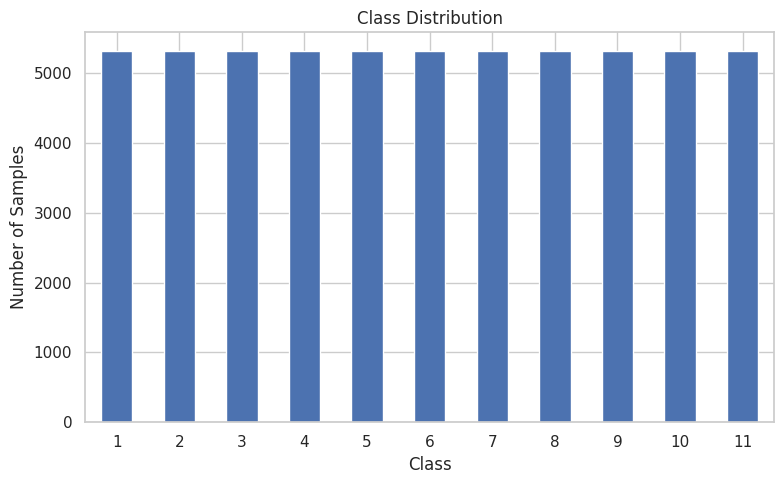

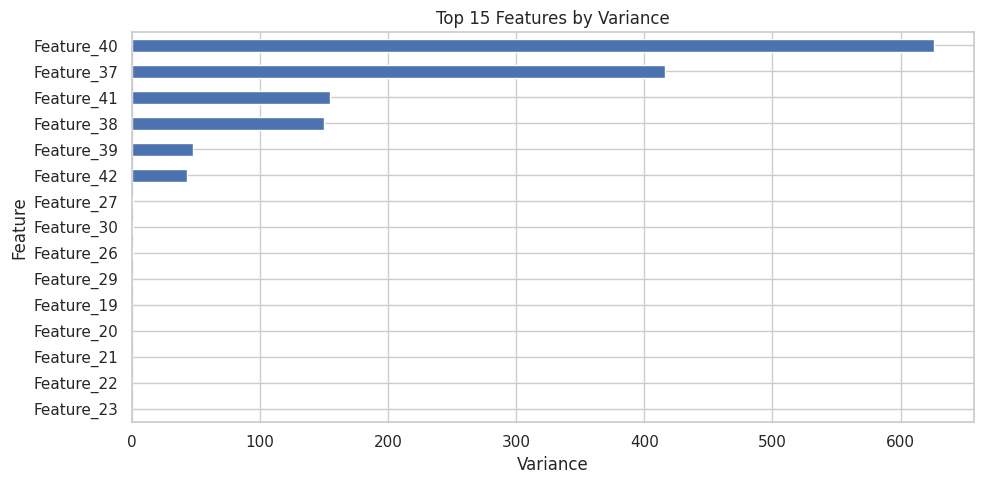


Audit summary:
rows: 58508
columns: 49
num_features: 48
num_classes: 11
missing_values_total: 0
duplicate_rows: 0
zero_variance_features: 0


In [9]:
# 6. Plot 1: Class Distribution
# Visualizing class counts to spot potential bias in the training data.
plt.figure(figsize=(8,5))
class_counts.plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 7. Plot 2: Top 15 Feature Variances
# Horizontal bar chart showing which 15 features have the highest spread.
plt.figure(figsize=(10,5))
variance_series.head(15).sort_values().plot(kind="barh")
plt.title("Top 15 Features by Variance")
plt.xlabel("Variance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# 8. audit summary
# Creating a dictionary for a final 'health report' of the dataset.
audit_summary = {
    "rows": df.shape[0],
    "columns": df.shape[1],
    "num_features": len(feature_cols),
    "num_classes": df["Class"].nunique(),
    "missing_values_total": int(df.isnull().sum().sum()),
    "duplicate_rows": int(df.duplicated().sum()),
    "zero_variance_features": len(zero_variance_features)
}

print("\nAudit summary:")
for k, v in audit_summary.items():
    print(f"{k}: {v}")